Team members:
* Andrew Maciborski
* Vincent Chau
* Lyda Taing
* Christie Wong
* Daniel Remedios

In [67]:

import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
import seaborn as sns

# **CS105 Mini Project**

The purpose of this project is to investigate the prevalence of AI-generated content on social media platforms and how users percieve its impact.

The keys question for this research are focused on:
* Which social media platforms have the highest reported prevalence of AI content?
* Does the amount of time spent on social media correlate with AI awareness?
* How do ethical concerns impact a user's likelihood to verify content?


In this lab, we will analyze data from a survey created by the combination of CS105 students' study topics for a mini project. The survey were mainly collected from students in CS111 and CS105. From the raw data, we created a new dataset on only the attribute related to our topic.

The data file is : Mini-Project Survey response.csv.


In [68]:
# Loading data
df_OG = pd.read_csv("Mini-Project Survey response.csv")
df_OG.head()

# filtering and rename
df = pd.DataFrame({
    'Platform': df_OG.iloc[:, 30],          # What is your main social media platform?
    'Verify_Likelihood': df_OG.iloc[:, 31], # How likely are you to verify if the content you see on social media is AI-generated or not?
    'Sentiment': df_OG.iloc[:, 32],         # How do you feel about AI-generated content on your social media feed?
    'AI_Videos': df_OG.iloc[:, 33],         # How frequently do you see AI-generated content of each of the following? [Videos]
    'AI_Images': df_OG.iloc[:, 34],         # How frequently do you see AI-generated content of each of the following? [Images]
    'AI_Influencers': df_OG.iloc[:, 35],    # How frequently do you see AI-generated content of each of the following? [AI Influencers/Celebrities]
    'AI_Text': df_OG.iloc[:, 36],           # How frequently do you see AI-generated content of each of the following? [Text]
    'AI_Music': df_OG.iloc[:, 37],          # How frequently do you see AI-generated content of each of the following? [Music]
    'AI_Voice': df_OG.iloc[:, 38],          # How frequently do you see AI-generated content of each of the following? [Voiceover]
    'Ethical' : df_OG.iloc[:, 39],          # How concerned are you about the ethical status of AI generated content on social media? (Misinformation, copyright, …)
    'GPA': df_OG.iloc[:, 13],               # Numeric GPA
    'Age': df_OG.iloc[:, 14]                # Numeric Age
})

# Drop empty rows
df = df.dropna()
print(df.head())

     Platform  Verify_Likelihood  Sentiment  AI_Videos  AI_Images  \
30    discord                3.0        3.0      Often  Sometimes   
73  Instagram                4.0        1.0      Often      Often   
74     TikTok                3.0        1.0      Often  Sometimes   
75  Instagram                3.0        1.0      Often      Often   
76  Instagram                3.0        3.0  Sometimes  Sometimes   

   AI_Influencers    AI_Text   AI_Music AI_Voice  Ethical          GPA  Age  
30         Rarely  Sometimes     Rarely   Rarely      2.0   3.0 – 3.33   20  
73          Often      Often     Rarely   Always      5.0  3.33 – 3.67   19  
74      Sometimes      Often  Sometimes    Often      5.0  3.33 – 3.67   19  
75      Sometimes      Often      Often   Always      5.0   3.0 – 3.33   19  
76      Sometimes     Rarely  Sometimes    Often      3.0   3.67 – 4.0   21  


In [69]:
# data format
# Verify_Likelihood range from (very unlikely) 1 to 5(very likely)
# Sentiment range from (very negative) 1 to 5(very positive)
# frequently do see AI-generated content: never(1), rarely(2), sometime(3), often(4), always(5)
# ethical concern level (not at all) 1 to 5(highly concern)

# Format never(1), rarely(2), sometime(3), often(4), always(5)
freq_map = {
    'Never': 1,
    'Rarely': 2,
    'Sometimes': 3,
    'Often': 4,
    'Always': 5
}

# Standardize frequency columns
freq_cols = ['AI_Videos', 'AI_Images', 'AI_Influencers', 'AI_Text', 'AI_Music', 'AI_Voice']
for col in freq_cols:
  df[col] = df[col].map(freq_map)

# convert string to number
#convert to number
for col in ['Age','Verify_Likelihood', 'Sentiment', 'Ethical']:
  df[col] = pd.to_numeric(df[col].astype(str).str.extract('(\d+\.?\d*)')[0], errors='coerce')

df.head()



,Platform,Verify_Likelihood,Sentiment,AI_Videos,AI_Images,AI_Influencers,AI_Text,AI_Music,AI_Voice,Ethical,GPA,Age
30,discord,3.0,3.0,4,3,2,3,2,2,2.0,3.0 – 3.33,20
73,Instagram,4.0,1.0,4,4,4,4,2,5,5.0,3.33 – 3.67,19
74,TikTok,3.0,1.0,4,3,3,4,3,4,5.0,3.33 – 3.67,19
75,Instagram,3.0,1.0,4,4,3,4,4,5,5.0,3.0 – 3.33,19
76,Instagram,3.0,3.0,3,3,3,2,3,4,3.0,3.67 – 4.0,21


## **I. Data Exploration and Visualization**

Create at least 8 visualizations, with at least 6 different types.
These visualizations should go beyond basic pie or bar charts and combine variables in ways that reveal relationships, patterns, or insights from the data.

For each visualization:
* Explain what you are trying to show or learn with this visual.
* Perform the necessary computations and generate the visualization using
Python.
* Analyze and interpret the results in the context of your question or
hypothesis.

### **1. Average Frequency of AI Content Types**
In this section, we want to determine the type of AI contents such as 'Videos', 'Images', 'Influencers', 'Text', 'Music', 'Voiceover' that the students encounter on social media. we will select the top 6 popular media platform according to the survey and use the mean value over all user respond to the AI content that apear on their feed.

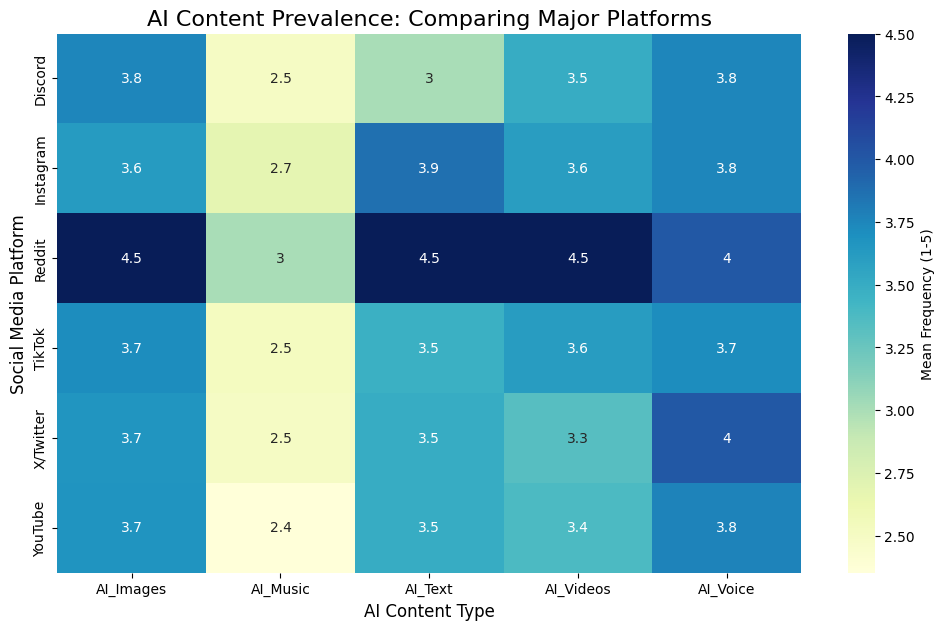

In [70]:
# the top 6 social media platform from survey
top_platforms = df['Platform'].value_counts().nlargest(6).index

joint = df[df['Platform'].isin(top_platforms)].pivot_table(
    values=['AI_Videos', 'AI_Images', 'AI_Text', 'AI_Music', 'AI_Voice'],
    index='Platform',
    aggfunc='mean'
)

plt.figure(figsize=(12, 7))
sns.heatmap(joint, annot=True, cmap="YlGnBu", cbar_kws={'label': 'Mean Frequency (1-5)'})

plt.title('AI Content Prevalence: Comparing Major Platforms', size=16)
plt.xlabel('AI Content Type', size=12)
plt.ylabel('Social Media Platform', size=12)
plt.show()

**Explaination**: From the heatmap above, it shows that most of the student use Reddit and most likely see an AI image, AI text and AI video over other platform. On the otherhand, across every platform, it apears that the AI music is less likely to apear on the user feed.

### **2. User Sentiment by Platform**

In this section, we want to see the relationship between the social media plateform and the distrubute of the user sentimental on the feed produced by AI.

Sentiment_5  Very Negative  Somewhat Negative    Neutral  Somewhat Positive  \
Platform                                                                      
Discord          25.000000          50.000000  25.000000           0.000000   
Instagram        32.467532          28.571429  33.766234           3.896104   
Reddit           50.000000          50.000000   0.000000           0.000000   
TikTok           42.857143          14.285714  33.333333           9.523810   
X/Twitter        66.666667          33.333333   0.000000           0.000000   
YouTube          32.352941          38.235294  23.529412           2.941176   

Sentiment_5  Very Positive  
Platform                    
Discord           0.000000  
Instagram         1.298701  
Reddit            0.000000  
TikTok            0.000000  
X/Twitter         0.000000  
YouTube           2.941176  


<Figure size 1200x800 with 0 Axes>

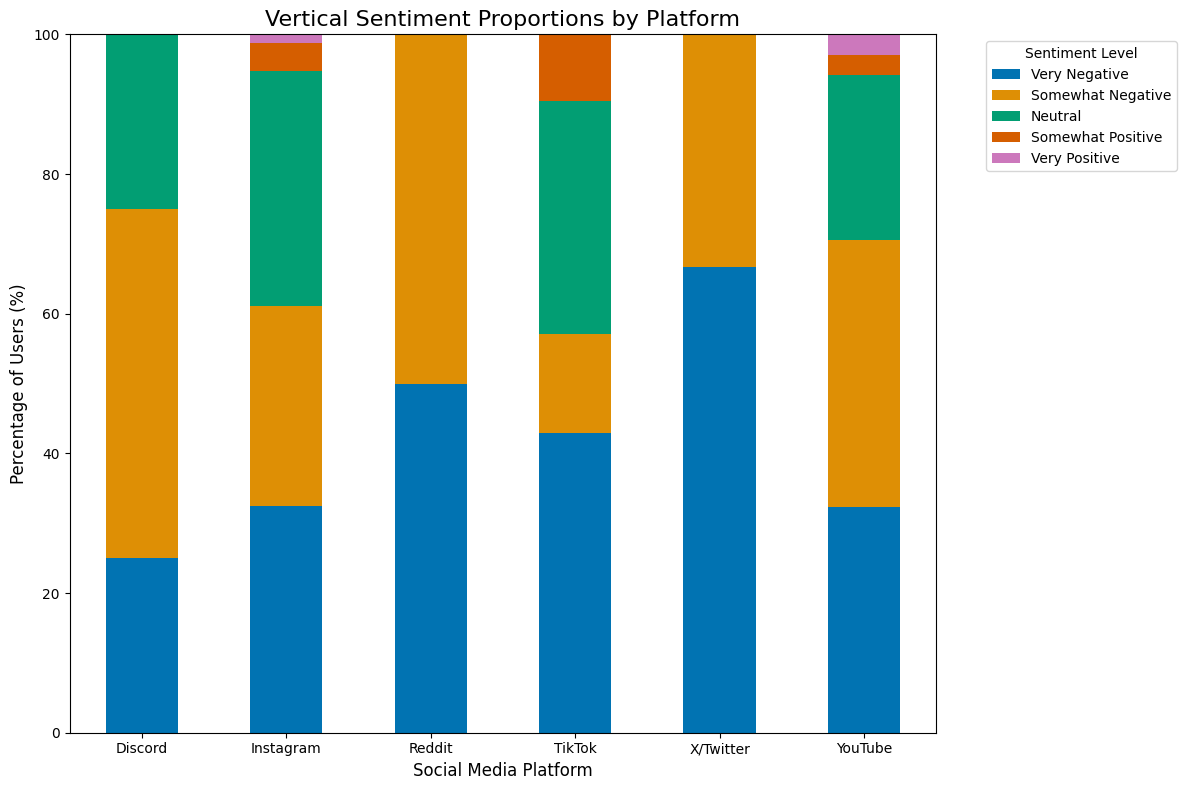

In [77]:

df_top = df[df['Platform'].isin(top_platforms)].copy()

# Define 5 bins
labels_5 = ['Very Negative', 'Somewhat Negative', 'Neutral', 'Somewhat Positive', 'Very Positive']
df_top['Sentiment_5'] = pd.cut(df_top['Sentiment'], bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5], labels=labels_5)

#create the frequency table
ct = pd.crosstab(df_top['Platform'], df_top['Sentiment_5'])

# Normalize to get percentages
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
print(ct_pct)

colors = sns.color_palette('colorblind', n_colors=ct.shape[1])
plt.figure(figsize=(12, 8))
ct_pct.plot(kind='bar', stacked=True, color=colors, figsize=(12, 8))
plt.title('Vertical Sentiment Proportions by Platform', size=16)
plt.ylabel('Percentage of Users (%)', size=12)
plt.xlabel('Social Media Platform', size=12)
plt.legend(title='Sentiment Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


**Explaination**: From the graph in this section, it illustrates that the  majority of the users have somewhat negative or negative toward the AI content on the social media. We can see that on X/Twitter, there are only somewhat negative or negative responce from the user. It also shows that there are a small percentage of user on Youtube has a positive review on AI content, however, it is still less than 5% of the youtube user.

### **3.**

**Explaination**:

### **4.**

**Explaination**:

### **5.**

**Explaination**:

### **6.**

**Explaination**:

### **7.**

**Explaination**:

### **8.**

**Explaination**:

## **II. Formulating and Testing Hypotheses**
Clearly state at least 3 hypotheses or predictions based on your EDA.

For each hypothesis:
* Describe and justify the statistical test you are using.
* Perform the test using Python.
*: Analyze the results and draw a conclusion.

Use at least 2 different statistical tests across all hypotheses: at least one correlation analysis and a chi-squared test.

### **Hypothese 1**:


**Test**:


**Analyze and Conclusion**:



### **Hypothese 2**:


**Test**:

**Analyze and Conclusion**:



### **Hypothese 3**:


**Test**:

**Analyze and Conclusion**:



## Conclusion


## Group Contrubution


* Andrew Maciborski:
* Vincent Chau:
* Lyda Taing: Cleaning data, the frist 2 graphs
* Christie Wong:
* Daniel Remedios:



In [72]:
#submisson
#!sudo apt-get update
#!sudo apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic pandoc
#!pip install pypandoc
#!jupyter nbconvert --log-level DEBUG --to pdf "<file name>.ipynb"